MODEL/CODE LOGIC DERIVED FROM:

https://www.datasciencewithmarco.com/blog/time-llm-reprogram-an-llm-for-time-series-forecasting

AND

https://github.com/marcopeix/time-series-analysis/blob/master/TimeLLM.ipynb

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import mean_squared_error, mean_absolute_error
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

from transformers import GPT2Model, GPT2Config
import datetime

np.random.seed(42)
torch.manual_seed(42)

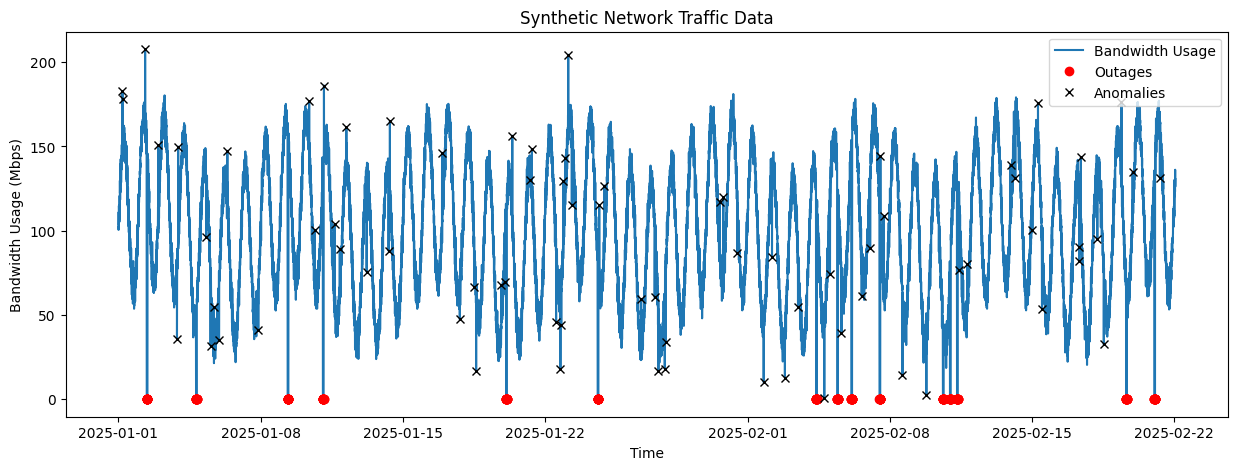

In [2]:
def generate_network_data(n_samples=15000, freq='5min'):
    start_time = pd.to_datetime('2025-01-01 00:00:00')
    time_index = pd.date_range(start=start_time, periods=n_samples, freq=freq)

    t = np.arange(n_samples)

    bandwidth = 100 + 50 * np.sin(2 * np.pi * t / (24 * 12)) + 20 * np.sin(2 * np.pi * t / (7 * 24 * 12))
    bandwidth += np.random.normal(0, 5, n_samples)

    latency = 10 + 0.1 * bandwidth + np.random.normal(0, 2, n_samples)
    packet_loss = np.random.exponential(0.1, n_samples)

    outage_indicator = np.zeros(n_samples)
    outage_starts = np.random.choice(range(100, n_samples-100, 100), size=15, replace=False)
    for start in outage_starts:
        outage_indicator[start:start+12] = 1


        bandwidth[start:start+12] = 0
        latency[start:start+12] = 100


        packet_loss[start:start+12] = 10

    anomaly_score = np.zeros(n_samples)

    anomaly_points = np.random.choice(range(n_samples), size=75, replace=False)
    anomaly_score[anomaly_points] = np.random.uniform(1, 5, 75)



    bandwidth[anomaly_points] += np.random.uniform(20, 50, 75) * np.random.choice([-1, 1], 75)

    hour = time_index.hour

    day = time_index.dayofweek
    hour_sin = np.sin(2 * np.pi * hour / 24)
    hour_cos = np.cos(2 * np.pi * hour / 24)
    day_sin = np.sin(2 * np.pi * day / 7)

    day_cos = np.cos(2 * np.pi * day / 7)

    df = pd.DataFrame({
        'timestamp': time_index,
        'bandwidth_usage': bandwidth,
        'latency': latency,
        'packet_loss': packet_loss,
        'outage_indicator': outage_indicator,
        'anomaly_score': anomaly_score,
        'hour_sin': hour_sin,
        'hour_cos': hour_cos,
        'day_sin': day_sin,
        'day_cos': day_cos
    })

    return df

df = generate_network_data()
df.set_index('timestamp', inplace=True)

plt.figure(figsize=(15, 5))

plt.plot(df.index, df['bandwidth_usage'], label='Bandwidth Usage')
plt.plot(df.index[df['outage_indicator'] == 1], df['bandwidth_usage'][df['outage_indicator'] == 1], 'ro', label='Outages')
plt.plot(df.index[df['anomaly_score'] > 0], df['bandwidth_usage'][df['anomaly_score'] > 0], 'kx', label='Anomalies')
plt.title('Synthetic Network Traffic Data')
plt.xlabel('Time')
plt.ylabel('Bandwidth Usage (Mbps)')
plt.legend()
plt.show()

In [3]:
features = ['bandwidth_usage', 'latency', 'packet_loss', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos']
data_scaler = MinMaxScaler()
continuous_features = ['bandwidth_usage', 'latency', 'packet_loss']
df_scaled_continuous = pd.DataFrame(
    data_scaler.fit_transform(df[continuous_features]),
    columns=continuous_features,
    index=df.index
)


df_scaled = df_scaled_continuous.join(df[['hour_sin', 'hour_cos', 'day_sin', 'day_cos']])




def create_sequences(data, seq_length=24):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data.iloc[i:i+seq_length][features].values)
        y.append(data.iloc[i+seq_length]['bandwidth_usage'])
    return np.array(X), np.array(y)

seq_length = 24
X, y = create_sequences(df_scaled, seq_length)

train_size = int(0.7 * len(X))
val_size = int(0.1 * len(X))


test_size = len(X) - train_size - val_size

X_train, X_val, X_test = X[:train_size], X[train_size:train_size+val_size], X[train_size+val_size:]
y_train, y_val, y_test = y[:train_size], y[train_size:train_size+val_size], y[train_size+val_size:]

X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train)
X_val_tensor = torch.FloatTensor(X_val)
y_val_tensor = torch.FloatTensor(y_val)


X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test)

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TimeSeriesDataset(X_train_tensor, y_train_tensor)
val_dataset = TimeSeriesDataset(X_val_tensor, y_val_tensor)
test_dataset = TimeSeriesDataset(X_test_tensor, y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)



In [4]:
from torch.cuda.amp import GradScaler
from torch import amp

class TimeLLM(nn.Module):
    def __init__(self, input_dim=7, hidden_dim=768, gpt2_model='distilgpt2', prefix_length=40):
        super(TimeLLM, self).__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.prefix_length = prefix_length

        self.seq_length = seq_length

        self.input_projection = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, hidden_dim)
        )
        self.dropout = nn.Dropout(0.05)

        self.gpt2 = GPT2Model.from_pretrained(gpt2_model)
        for name, param in self.gpt2.named_parameters():
            if 'h.0' in name or 'h.1' in name or 'h.2' in name:
                param.requires_grad = False
            else:
                param.requires_grad = True

        self.output_layer = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )


        self.output_dropout = nn.Dropout(0.05)

        pos = torch.arange(prefix_length).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, hidden_dim, 2) * (-np.log(10000.0) / hidden_dim))

        pe = torch.zeros(1, prefix_length, hidden_dim)
        pe[0, :, 0::2] = torch.sin(pos * div_term)
        pe[0, :, 1::2] = torch.cos(pos * div_term)


        self.prefix_embedding = nn.Parameter(pe, requires_grad=True)

    def forward(self, x):
        batch_size = x.size(0)
        x = self.input_projection(x)
        x = self.dropout(x)

        prefix = self.prefix_embedding.repeat(batch_size, 1, 1)
        x = torch.cat([prefix, x], dim=1)

        with amp.autocast('cuda'):
            outputs = self.gpt2(inputs_embeds=x).last_hidden_state
        output = outputs[:, -1, :]
        output = self.output_dropout(output)
        output = self.output_layer(output)
        return output

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
time_llm = TimeLLM(input_dim=len(features), prefix_length=40).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(time_llm.parameters(), lr=0.0005)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)
scaler = GradScaler()

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

<ipython-input-4-df015a06e236>:69: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [5]:
class LSTMModel(nn.Module):
    def __init__(self, input_dim=3, hidden_dim=64, num_layers=2):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        output = self.fc(h_n[-1])
        return output





lstm_model = LSTMModel(input_dim=len(features)).to(device)
lstm_optimizer = torch.optim.Adam(lstm_model.parameters(), lr=0.001)

In [6]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scaler=None, scheduler=None, epochs=30):
    model.train()
    best_val_loss = float('inf')
    patience = 3
    patience_counter = 0
    for epoch in range(epochs):
        total_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            if scaler is not None:
                with amp.autocast('cuda'):
                    output = model(X_batch).squeeze()
                    loss = criterion(output, y_batch)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)


                scaler.update()
            else:
                output = model(X_batch).squeeze()
                loss = criterion(output, y_batch)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            total_loss += loss.item()

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                if scaler is not None:
                    with amp.autocast('cuda'):
                        output = model(X_batch).squeeze()
                        val_loss += criterion(output, y_batch).item()
                else:
                    output = model(X_batch).squeeze()
                    val_loss += criterion(output, y_batch).item()
        val_loss /= len(val_loader)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), f'{model.__class__.__name__}_best.pth')
            patience_counter = 0
        else:
            patience_counter += 1

        if scheduler is not None:
            scheduler.step()

        model.train()
        print(f'Epoch {epoch+1}/{epochs}, Train Loss: {total_loss/len(train_loader):.4f}, Val Loss: {val_loss:.4f}')

        if epoch > 5 and val_loss < 0.0015:
            print(f"Early stopping at epoch {epoch+1}")
            break
        if patience_counter >= patience:
            print(f"Early stopping due to no improvement after {patience} epochs")
            break

    model.load_state_dict(torch.load(f'{model.__class__.__name__}_best.pth'))
    return val_loss

print("Training Time-LLM...")
train_model(time_llm, train_loader, val_loader, criterion, optimizer, scaler, scheduler, epochs=30)

print("\nTraining LSTM...")
train_model(lstm_model, train_loader, val_loader, criterion, lstm_optimizer, None, epochs=10)

Training Time-LLM...
Epoch 1/30, Train Loss: 0.1512, Val Loss: 0.0039
Epoch 2/30, Train Loss: 0.0025, Val Loss: 0.0024
Epoch 3/30, Train Loss: 0.0020, Val Loss: 0.0025
Epoch 4/30, Train Loss: 0.0018, Val Loss: 0.0026
Epoch 5/30, Train Loss: 0.0018, Val Loss: 0.0020
Epoch 6/30, Train Loss: 0.0016, Val Loss: 0.0021
Epoch 7/30, Train Loss: 0.0017, Val Loss: 0.0022
Epoch 8/30, Train Loss: 0.0016, Val Loss: 0.0019
Epoch 9/30, Train Loss: 0.0016, Val Loss: 0.0020
Epoch 10/30, Train Loss: 0.0015, Val Loss: 0.0019
Epoch 11/30, Train Loss: 0.0016, Val Loss: 0.0019
Epoch 12/30, Train Loss: 0.0016, Val Loss: 0.0017
Epoch 13/30, Train Loss: 0.0015, Val Loss: 0.0023
Epoch 14/30, Train Loss: 0.0015, Val Loss: 0.0019
Epoch 15/30, Train Loss: 0.0014, Val Loss: 0.0018
Early stopping due to no improvement after 3 epochs

Training LSTM...
Epoch 1/10, Train Loss: 0.0258, Val Loss: 0.0054
Epoch 2/10, Train Loss: 0.0030, Val Loss: 0.0042
Epoch 3/10, Train Loss: 0.0025, Val Loss: 0.0035
Epoch 4/10, Train Los

0.002124508124931405

In [7]:
def evaluate_model(model, test_loader, criterion, scaler, feature_idx=0):
    model.eval()
    predictions, actuals = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            output = model(X_batch).squeeze()
            predictions.extend(output.cpu().numpy())
            actuals.extend(y_batch.cpu().numpy())

    predictions = np.array(predictions).reshape(-1, 1)
    actuals = np.array(actuals).reshape(-1, 1)

    dummy = np.zeros((len(predictions), 3))
    dummy[:, feature_idx] = predictions[:, 0]
    predictions = scaler.inverse_transform(dummy)[:, feature_idx]
    dummy[:, feature_idx] = actuals[:, 0]
    actuals = scaler.inverse_transform(dummy)[:, feature_idx]

    mse = mean_squared_error(actuals, predictions)
    mae = mean_absolute_error(actuals, predictions)

    return predictions, actuals, mse, mae

time_llm_preds, actuals, time_llm_mse, time_llm_mae = evaluate_model(time_llm, test_loader, criterion, data_scaler)
lstm_preds, _, lstm_mse, lstm_mae = evaluate_model(lstm_model, test_loader, criterion, data_scaler)

print(f"Time-LLM - MSE: {time_llm_mse:.4f}, MAE: {time_llm_mae:.4f}")
print(f"LSTM - MSE: {lstm_mse:.4f}, MAE: {lstm_mae:.4f}")

Time-LLM - MSE: 47.3013, MAE: 4.5619
LSTM - MSE: 54.0995, MAE: 4.8661


Found existing installation: scikit-learn 1.6.1
Uninstalling scikit-learn-1.6.1:
  Successfully uninstalled scikit-learn-1.6.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 76.0 MB/s eta 0:00:00


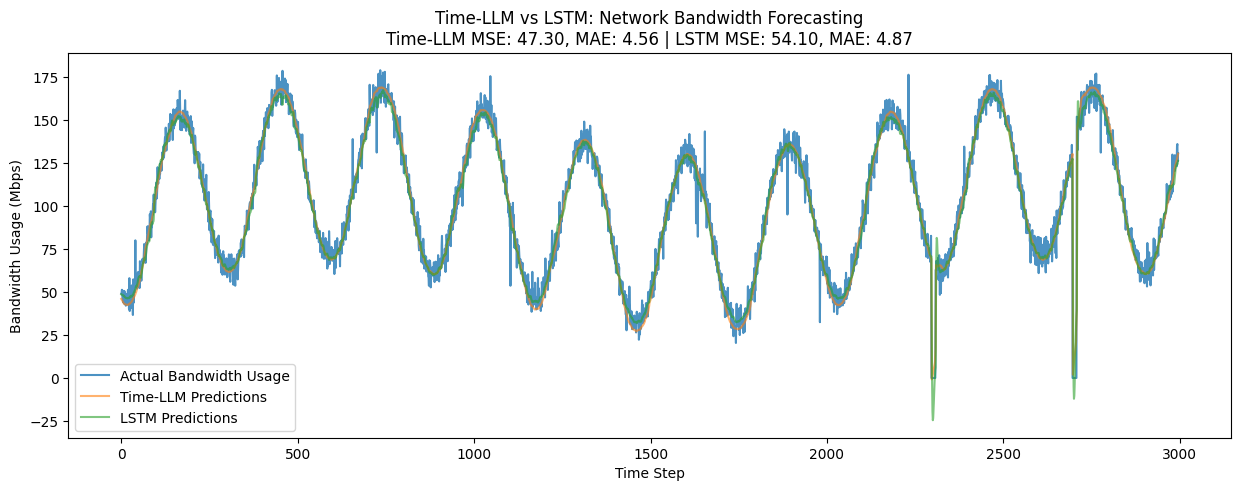

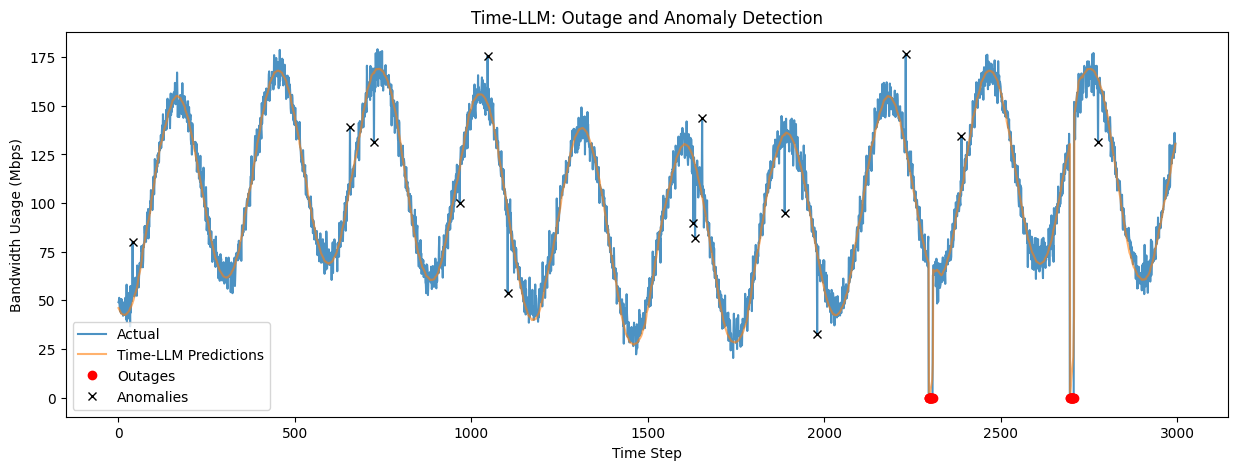

Classification Metrics:
Time-LLM Outage: Precision 1.00, Recall 0.58, F1 0.74, Support 24
LSTM Outage: Precision 0.94, Recall 0.62, F1 0.75, Support 24
Time-LLM Anomaly: Precision 0.62, Recall 0.93, F1 0.74, Support 14
LSTM Anomaly: Precision 0.48, Recall 0.93, F1 0.63, Support 14

Table 2: Classification Performance
| Model       | Class   | Precision | Recall | F1-Score | Support |
|-------------|---------|-----------|--------|----------|---------|
| Time-LLM    | Outage  | 1.00      | 0.58   | 0.74     | 24       |
|             | Anomaly | 0.62      | 0.93   | 0.74     | 14       |
| LSTM        | Outage  | 0.94      | 0.62   | 0.75     | 24       |
|             | Anomaly | 0.48      | 0.93   | 0.63     | 14       |


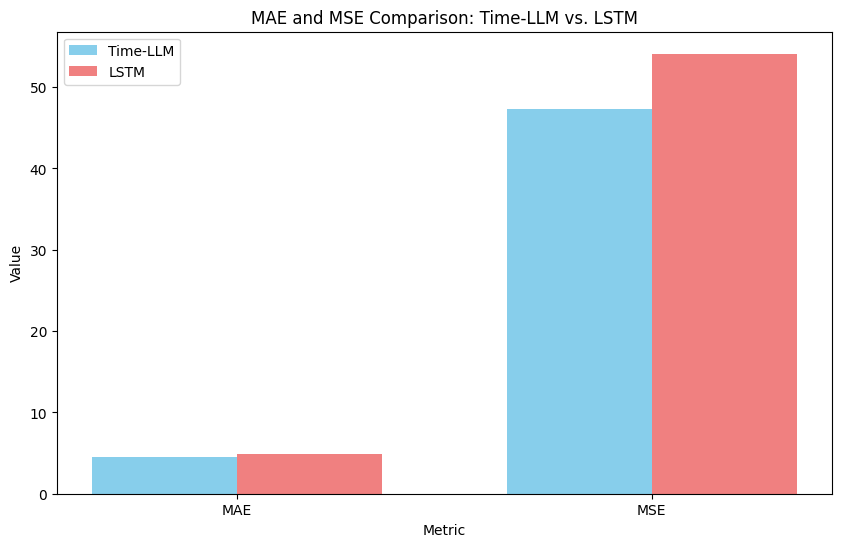

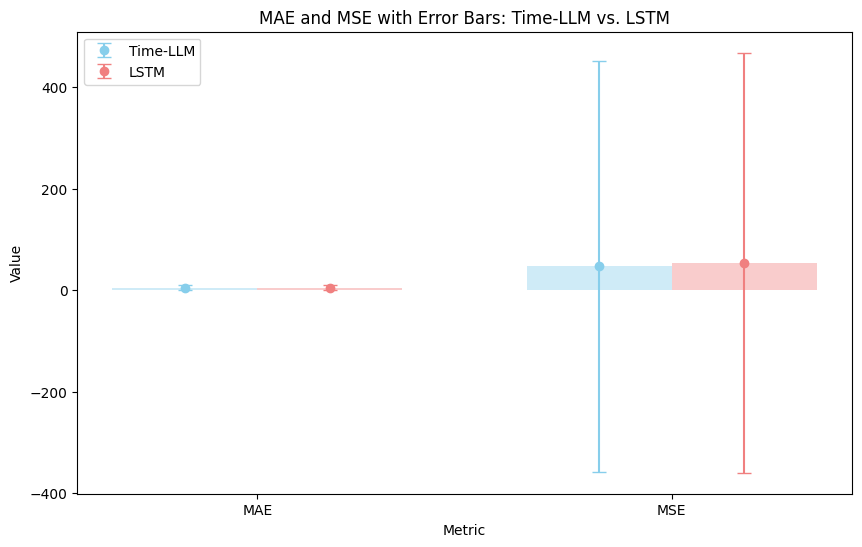

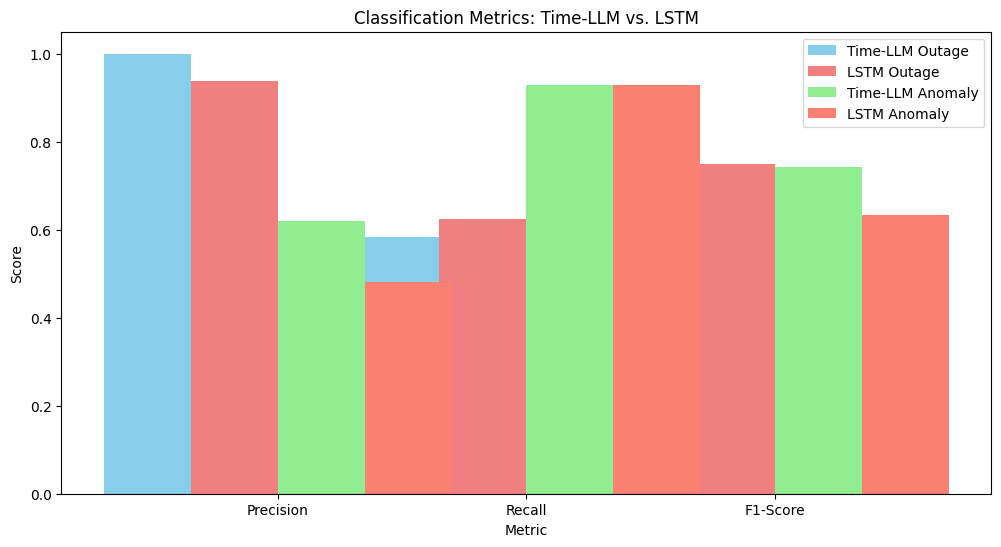


Example Time-LLM Predictions:

Example at Test Timestep 2296 (True: Outage)
Input (last timestep of sequence):
  Bandwidth: 82.74 Mbps
  Latency: 19.75 ms
  Packet Loss: 0.14%
Predicted Bandwidth: 69.23 Mbps
Actual Bandwidth: 0.00 Mbps
Absolute Error: 69.23 Mbps
Time-LLM Decision: Anomaly detected

Example at Test Timestep 40 (True: Anomaly)
Input (last timestep of sequence):
  Bandwidth: 55.00 Mbps
  Latency: 18.64 ms
  Packet Loss: 0.12%
Predicted Bandwidth: 48.72 Mbps
Actual Bandwidth: 80.10 Mbps
Absolute Error: 31.38 Mbps
Time-LLM Decision: Anomaly detected

Example at Test Timestep 0 (True: Normal)
Input (last timestep of sequence):
  Bandwidth: 49.23 Mbps
  Latency: 14.88 ms
  Packet Loss: 0.06%
Predicted Bandwidth: 46.05 Mbps
Actual Bandwidth: 49.11 Mbps
Absolute Error: 3.06 Mbps
Time-LLM Decision: Normal


In [8]:
!pip uninstall -y scikit-learn
!pip install scikit-learn==1.5.0

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

try:
    from sklearn.metrics import precision_recall_f1_support
    import sklearn
    print(f"Successfully imported precision_recall_f1_support (scikit-learn {sklearn.__version__})")
except ImportError:
    print("Warning: precision_recall_f1_support import failed. Using manual implementation.")
    def precision_recall_f1_support(y_true, y_pred, average='binary'):
        true_positives = np.sum((y_true == 1) & (y_pred == 1))
        predicted_positives = np.sum(y_pred == 1)
        actual_positives = np.sum(y_true == 1)
        precision = true_positives / predicted_positives if predicted_positives > 0 else 0.0
        recall = true_positives / actual_positives if actual_positives > 0 else 0.0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
        support = actual_positives
        return (precision, recall, f1, support)

plt.figure(figsize=(15, 5))
plt.plot(actuals, label='Actual Bandwidth Usage', alpha=0.8)
plt.plot(time_llm_preds, label='Time-LLM Predictions', alpha=0.6)
plt.plot(lstm_preds, label='LSTM Predictions', alpha=0.6)
plt.title(f'Time-LLM vs LSTM: Network Bandwidth Forecasting\nTime-LLM MSE: {time_llm_mse:.2f}, MAE: {time_llm_mae:.2f} | LSTM MSE: {lstm_mse:.2f}, MAE: {lstm_mae:.2f}')
plt.xlabel('Time Step')
plt.ylabel('Bandwidth Usage (Mbps)')
plt.legend()
plt.savefig('figure1.png')
plt.show()

try:
    test_start_idx = train_size + val_size + seq_length
    test_end_idx = test_start_idx + test_size
    test_df = df.iloc[test_start_idx:test_end_idx]
    outages = test_df['outage_indicator'].values
    anomalies = test_df['anomaly_score'].values
except NameError as e:
    print(f"Error: {e}. Ensure train_size, val_size, seq_length, test_size, df are defined (e.g., Cell 3).")
    raise

plt.figure(figsize=(15, 5))
plt.plot(actuals, label='Actual', alpha=0.8)
plt.plot(time_llm_preds, label='Time-LLM Predictions', alpha=0.6)
plt.plot(np.where(outages > 0)[0], actuals[outages > 0], 'ro', label='Outages')
plt.plot(np.where(anomalies > 0)[0], actuals[anomalies > 0], 'kx', label='Anomalies')
plt.title('Time-LLM: Outage and Anomaly Detection')
plt.xlabel('Time Step')
plt.ylabel('Bandwidth Usage (Mbps)')
plt.legend()

plt.savefig('figure2.png')
plt.show()

if not (hasattr(test_df, 'outage_indicator') and hasattr(test_df, 'anomaly_score')):
    print("Error: test_df missing 'outage_indicator' or 'anomaly_score'. Cannot compute metrics.")
    raise AttributeError("Required columns missing in test_df")
y_true_outage = (test_df['outage_indicator'] > 0).astype(int)
y_pred_outage_time_llm = (time_llm_preds < 10.0).astype(int)
y_pred_outage_lstm = (lstm_preds < 10.0).astype(int)
y_true_anomaly = (test_df['anomaly_score'] > 0).astype(int)
y_pred_anomaly_time_llm = (abs(time_llm_preds - actuals) > 20.0).astype(int)
y_pred_anomaly_lstm = (abs(lstm_preds - actuals) > 20.0).astype(int)

def safe_precision_recall_f1_support(y_true, y_pred, class_name):
    if sum(y_pred) == 0:
        print(f"Warning: No {class_name} predicted. Returning zeros for precision, F1.")
        return (0.0, y_true.sum() / len(y_true) if y_true.sum() > 0 else 0.0, 0.0, y_true.sum())
    return precision_recall_f1_support(y_true, y_pred, average='binary')

outage_metrics_time_llm = safe_precision_recall_f1_support(y_true_outage, y_pred_outage_time_llm, "outages (Time-LLM)")
outage_metrics_lstm = safe_precision_recall_f1_support(y_true_outage, y_pred_outage_lstm, "outages (LSTM)")
anomaly_metrics_time_llm = safe_precision_recall_f1_support(y_true_anomaly, y_pred_anomaly_time_llm, "anomalies (Time-LLM)")
anomaly_metrics_lstm = safe_precision_recall_f1_support(y_true_anomaly, y_pred_anomaly_lstm, "anomalies (LSTM)")

print("Classification Metrics:")
print(f"Time-LLM Outage: Precision {outage_metrics_time_llm[0]:.2f}, Recall {outage_metrics_time_llm[1]:.2f}, F1 {outage_metrics_time_llm[2]:.2f}, Support {outage_metrics_time_llm[3]}")
print(f"LSTM Outage: Precision {outage_metrics_lstm[0]:.2f}, Recall {outage_metrics_lstm[1]:.2f}, F1 {outage_metrics_lstm[2]:.2f}, Support {outage_metrics_lstm[3]}")
print(f"Time-LLM Anomaly: Precision {anomaly_metrics_time_llm[0]:.2f}, Recall {anomaly_metrics_time_llm[1]:.2f}, F1 {anomaly_metrics_time_llm[2]:.2f}, Support {anomaly_metrics_time_llm[3]}")
print(f"LSTM Anomaly: Precision {anomaly_metrics_lstm[0]:.2f}, Recall {anomaly_metrics_lstm[1]:.2f}, F1 {anomaly_metrics_lstm[2]:.2f}, Support {anomaly_metrics_lstm[3]}")

print("\nTable 2: Classification Performance")
print("| Model       | Class   | Precision | Recall | F1-Score | Support |")
print("|-------------|---------|-----------|--------|----------|---------|")
print(f"| Time-LLM    | Outage  | {outage_metrics_time_llm[0]:.2f}      | {outage_metrics_time_llm[1]:.2f}   | {outage_metrics_time_llm[2]:.2f}     | {outage_metrics_time_llm[3]}       |")
print(f"|             | Anomaly | {anomaly_metrics_time_llm[0]:.2f}      | {anomaly_metrics_time_llm[1]:.2f}   | {anomaly_metrics_time_llm[2]:.2f}     | {anomaly_metrics_time_llm[3]}       |")
print(f"| LSTM        | Outage  | {outage_metrics_lstm[0]:.2f}      | {outage_metrics_lstm[1]:.2f}   | {outage_metrics_lstm[2]:.2f}     | {outage_metrics_lstm[3]}       |")
print(f"|             | Anomaly | {anomaly_metrics_lstm[0]:.2f}      | {anomaly_metrics_lstm[1]:.2f}   | {anomaly_metrics_lstm[2]:.2f}     | {anomaly_metrics_lstm[3]}       |")

plt.figure(figsize=(10, 6))
labels = ['MAE', 'MSE']
time_llm_metrics = [time_llm_mae, time_llm_mse]
lstm_metrics = [lstm_mae, lstm_mse]
x = np.arange(len(labels))
width = 0.35

plt.bar(x - width/2, time_llm_metrics, width, label='Time-LLM', color='skyblue')
plt.bar(x + width/2, lstm_metrics, width, label='LSTM', color='lightcoral')
plt.xlabel('Metric')
plt.ylabel('Value')
plt.title('MAE and MSE Comparison: Time-LLM vs. LSTM')
plt.xticks(x, labels)
plt.legend()
plt.savefig('figure3.png')
plt.show()

plt.figure(figsize=(10, 6))

time_llm_errors = np.abs(time_llm_preds - actuals)
lstm_errors = np.abs(lstm_preds - actuals)
time_llm_std = [np.std(time_llm_errors), np.std((time_llm_preds - actuals)**2)]


lstm_std = [np.std(lstm_errors), np.std((lstm_preds - actuals)**2)]

plt.errorbar(x - width/2, time_llm_metrics, yerr=time_llm_std, fmt='o', label='Time-LLM', capsize=5, color='skyblue')
plt.errorbar(x + width/2, lstm_metrics, yerr=lstm_std, fmt='o', label='LSTM', capsize=5, color='lightcoral')
plt.bar(x - width/2, time_llm_metrics, width, alpha=0.4, color='skyblue')
plt.bar(x + width/2, lstm_metrics, width, alpha=0.4, color='lightcoral')
plt.xlabel('Metric')
plt.ylabel('Value')
plt.title('MAE and MSE with Error Bars: Time-LLM vs. LSTM')
plt.xticks(x, labels)
plt.legend()
plt.savefig('figure4.png')
plt.show()

plt.figure(figsize=(12, 6))
metrics = ['Precision', 'Recall', 'F1-Score']
time_llm_outage = [outage_metrics_time_llm[0], outage_metrics_time_llm[1], outage_metrics_time_llm[2]]
lstm_outage = [outage_metrics_lstm[0], outage_metrics_lstm[1], outage_metrics_lstm[2]]
time_llm_anomaly = [anomaly_metrics_time_llm[0], anomaly_metrics_time_llm[1], anomaly_metrics_time_llm[2]]
lstm_anomaly = [anomaly_metrics_lstm[0], anomaly_metrics_lstm[1], anomaly_metrics_lstm[2]]

x = np.arange(len(metrics))
plt.bar(x - width*1.5, time_llm_outage, width, label='Time-LLM Outage', color='skyblue')
plt.bar(x - width/2, lstm_outage, width, label='LSTM Outage', color='lightcoral')
plt.bar(x + width/2, time_llm_anomaly, width, label='Time-LLM Anomaly', color='lightgreen')
plt.bar(x + width*1.5, lstm_anomaly, width, label='LSTM Anomaly', color='salmon')
plt.xlabel('Metric')

plt.ylabel('Score')
plt.title('Classification Metrics: Time-LLM vs. LSTM')
plt.xticks(x, metrics)
plt.legend()
plt.savefig('figure5.png')

plt.show()

print("\nExample Time-LLM Predictions:")
try:
    X_test, y_test = test_dataset.X, test_dataset.y
    X_test_unscaled = X_test.clone().cpu().numpy()
    for i in range(X_test.shape[2]):
        if i < 3:
            dummy = np.zeros((X_test.shape[0], 3))
            dummy[:, i] = X_test_unscaled[:, -1, i]
            X_test_unscaled[:, -1, i] = data_scaler.inverse_transform(dummy)[:, i]

    outage_indices = np.where(outages > 0)[0]
    anomaly_indices = np.where((anomalies > 0) & (outages == 0))[0]
    normal_indices = np.where((outages == 0) & (anomalies == 0))[0]

    example_indices = [
        outage_indices[0] if len(outage_indices) > 0 else None,
        anomaly_indices[0] if len(anomaly_indices) > 0 else None,
        normal_indices[0] if len(normal_indices) > 0 else None
    ]

    for idx in example_indices:
        if idx is None:
            print(f"No {'outage' if idx == example_indices[0] else 'anomaly' if idx == example_indices[1] else 'normal'} found in test set")
            continue
        input_last = X_test_unscaled[idx, -1, :3]
        pred = time_llm_preds[idx]
        actual = actuals[idx]
        error = abs(pred - actual)
        if pred < 10.0:
            classification = "Outage detected"
        elif error > 20.0:
            classification = "Anomaly detected"
        else:
            classification = "Normal"
        true_label = "Outage" if outages[idx] > 0 else ("Anomaly" if anomalies[idx] > 0 else "Normal")
        print(f"\nExample at Test Timestep {idx} (True: {true_label})")
        print(f"Input (last timestep of sequence):")
        print(f"  Bandwidth: {input_last[0]:.2f} Mbps")
        print(f"  Latency: {input_last[1]:.2f} ms")
        print(f"  Packet Loss: {input_last[2]:.2f}%")
        print(f"Predicted Bandwidth: {pred:.2f} Mbps")
        print(f"Actual Bandwidth: {actual:.2f} Mbps")
        print(f"Absolute Error: {error:.2f} Mbps")
        print(f"Time-LLM Decision: {classification}")
except NameError as e:
    print(f"Error: {e}. Ensure test_dataset, data_scaler are defined (e.g., Cell 3 or 7).")